In [1]:
from pathlib import Path
import polars as pl
import numpy as np

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-09/"
df_scenarios = pl.read_json(root + "scenarios.json")
print(df_scenarios)

ls = np.unique(df_scenarios["l"].to_numpy())
print(ls)

shape: (20, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 5   ┆ 0     ┆ periodic │
│ 150 ┆ 10  ┆ 0     ┆ periodic │
│ 150 ┆ 15  ┆ 0     ┆ periodic │
│ 150 ┆ 20  ┆ 0     ┆ periodic │
│ 150 ┆ 25  ┆ 0     ┆ periodic │
│ …   ┆ …   ┆ …     ┆ …        │
│ 150 ┆ 150 ┆ 0     ┆ random   │
│ 150 ┆ 10  ┆ 5     ┆ random   │
│ 150 ┆ 10  ┆ 10    ┆ random   │
│ 150 ┆ 10  ┆ 15    ┆ random   │
│ 150 ┆ 10  ┆ 0     ┆ homogen  │
└─────┴─────┴───────┴──────────┘
[  5  10  15  20  25  50 100 150]


/tmp/ipykernel_10821/3023123026.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("hot")


Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...


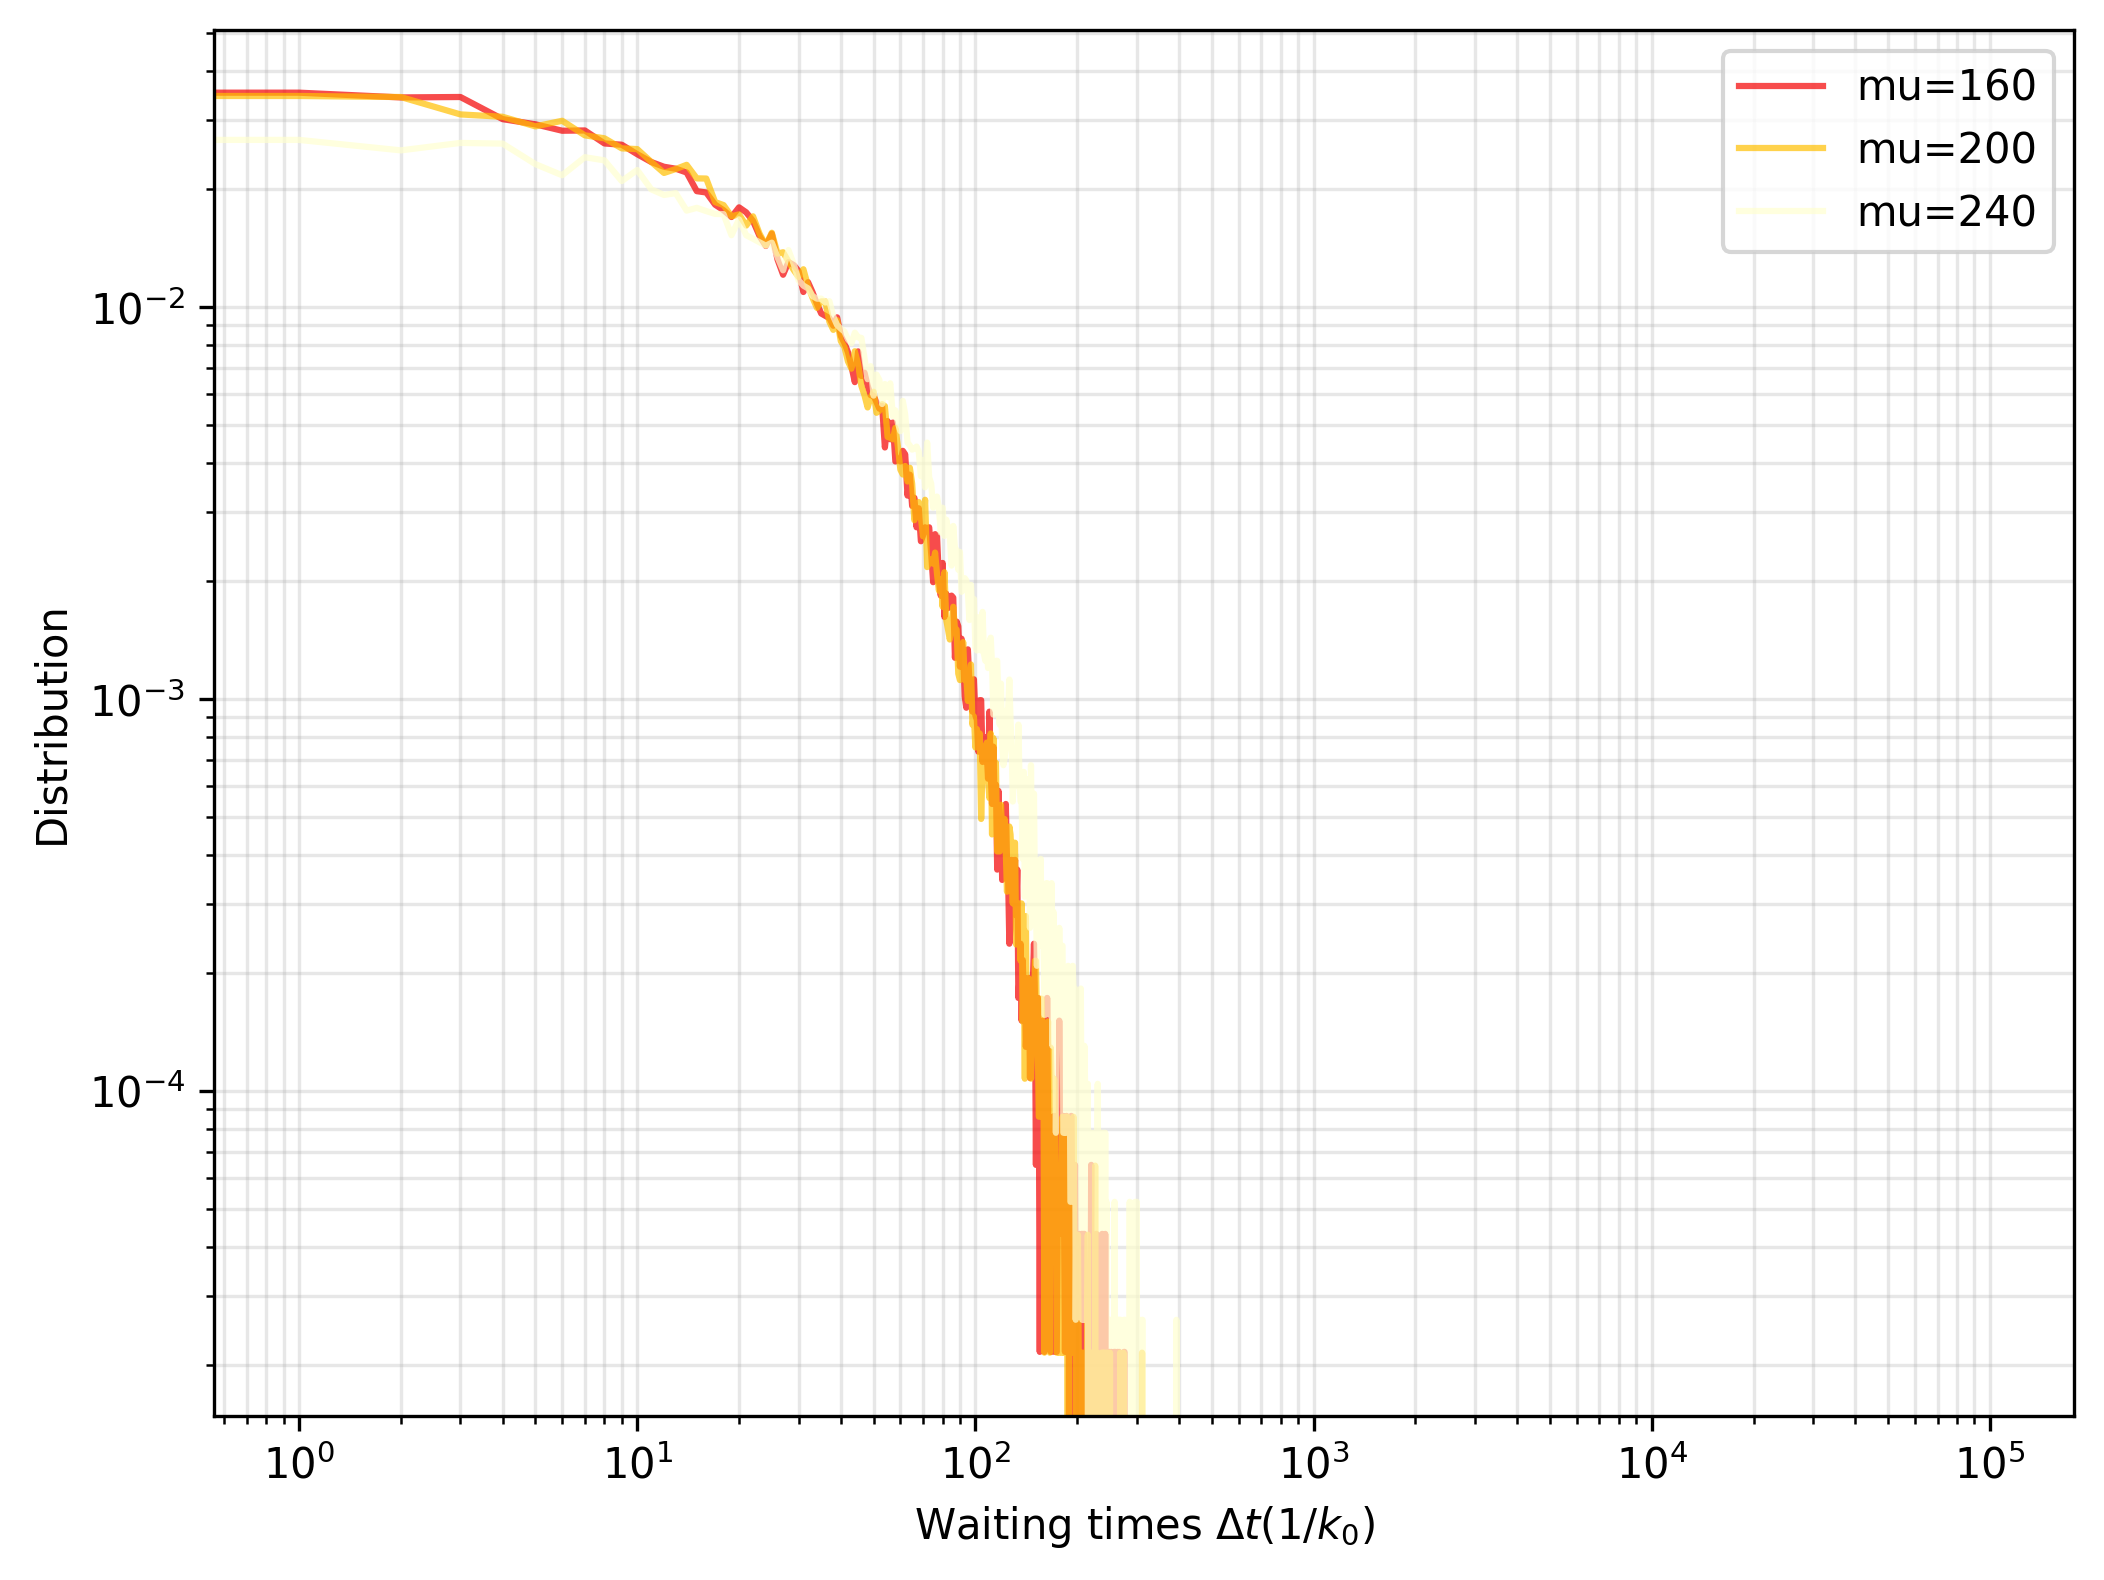

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nucleo.io.reading import finding_one_parquet

mus = [160, 200, 240]
theta = 60

params_shared = {
    'algo'  : "1S",
    'dstr'  : False,
    'fact'  : False, 
    'mode'  : "none", 

    "s"     : 150,
    "l"     : 10,
    "bpmin" : 0,
    "land"  : "random",
    "theta" : theta,

    'Kz'    : 0.00, 
    'Kp'    : 0.00, 
    'alphar': 0.00,
}

plt.figure(figsize=(8,6), dpi=300)
cmap = cm.get_cmap("hot")
colors = cmap(np.linspace(0.35,0.95, len(mus)))

for (mu, c) in zip(mus, colors):
    params.update({"mu": mu})
    df = finding_one_parquet(root, params)
    plt.plot(
        df['tbj_points'][0].to_numpy(), 
        df['tbj_distrib'][0].to_numpy(), 
        label=f"mu={mu}", 
        c=c, 
        alpha=0.70
    )

plt.loglog()
plt.xlabel(r"Waiting times $ \Delta t (1/k_0)$")
plt.ylabel("Distribution")
plt.grid(True, which="both", alpha=0.30)
plt.legend()
plt.savefig("supfig3_final.png", dpi=300)
plt.show()

/tmp/ipykernel_10821/3031055300.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("vanimo")


Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...
Scanning 178200 parquet files...


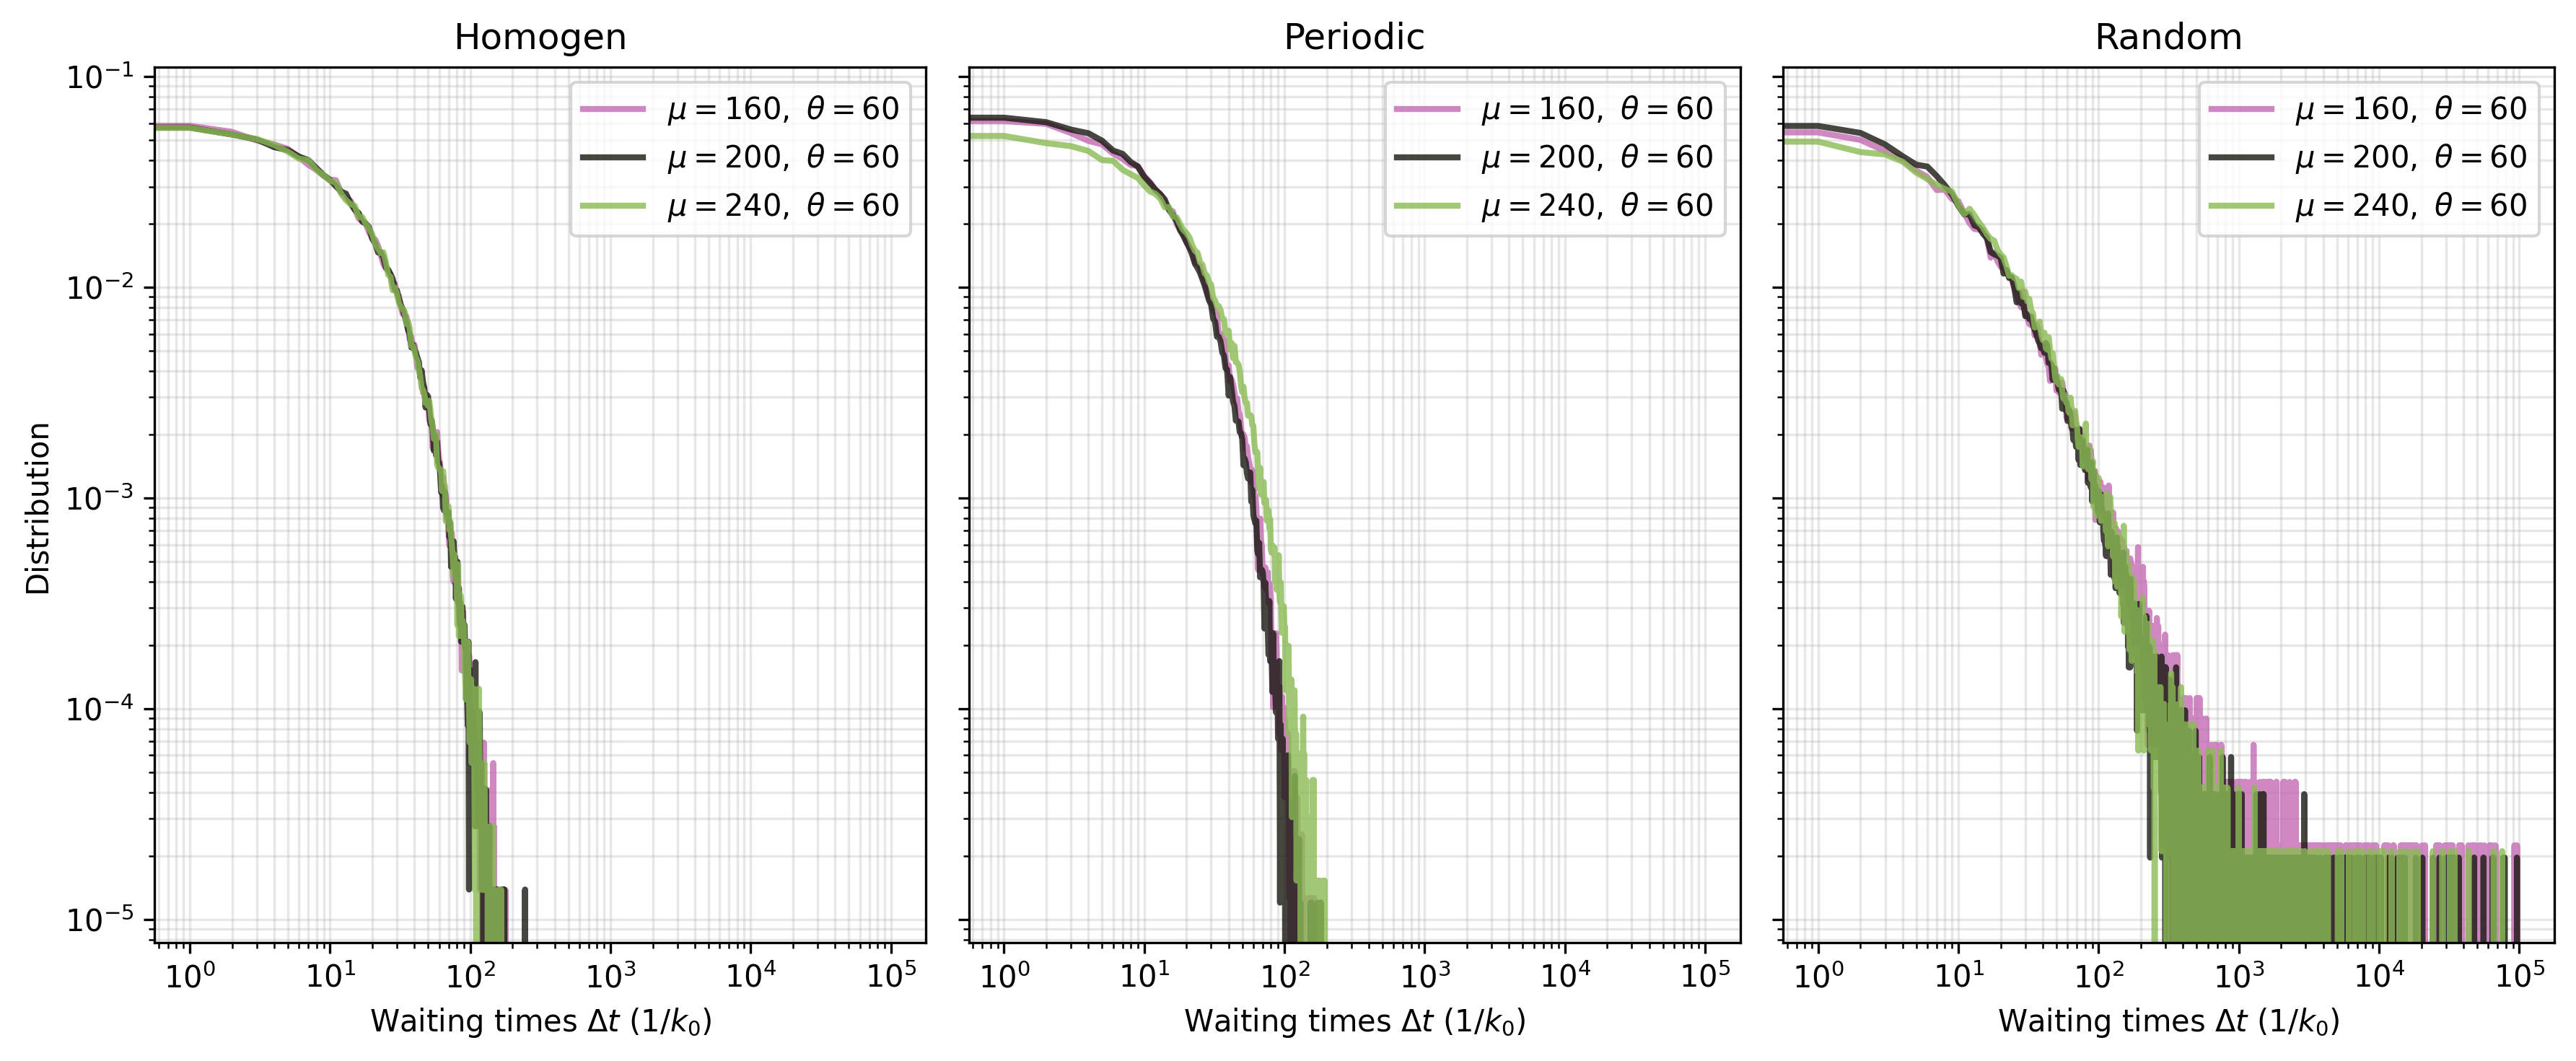

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.reading import finding_one_parquet

mus = [160, 200, 240]
theta = 60

params_shared = {
    'algo'  : "1S",
    'dstr'  : False,
    'fact'  : False,
    'mode'  : "none",

    "s"     : 150,
    "l"     : 10,
    "bpmin" : 0,
    "theta" : theta,

    'Kz'    : 0.00,
    'Kp'    : 0.00,
    'alphar': 0.00,
}

fig, axes = plt.subplots(1, 3, figsize=(12, 5), dpi=300, sharex=True, sharey=True)

cmap = cm.get_cmap("vanimo")
colors = cmap(np.linspace(0.15, 0.90, len(mus)))

for ax, land in zip(axes, ["homogen", "periodic", "random"]):

    params = params_shared.copy()
    params["land"] = land

    for mu, c in zip(mus, colors):

        params["mu"] = mu

        df = finding_one_parquet(root, params)

        ax.plot(
            df["tbj_points"][0].to_numpy(),
            df["tbj_distrib"][0].to_numpy(),
            color=c,
            alpha=0.8,
            lw=2,
            label=fr"$\mu={mu},\ \theta={theta}$"
        )

    ax.set_title(land.capitalize())
    ax.grid(True, which="both", alpha=0.30)
    ax.loglog()
    ax.legend()

axes[0].set_xlabel(r"Waiting times $\Delta t\ (1/k_0)$")
axes[1].set_xlabel(r"Waiting times $\Delta t\ (1/k_0)$")
axes[2].set_xlabel(r"Waiting times $\Delta t\ (1/k_0)$")
axes[0].set_ylabel("Distribution")

fig.tight_layout()
plt.savefig("supfig3_final.png", dpi=300, bbox_inches="tight")
plt.show()

# .